# Probability of survival

We plot the probablity that an edge will survive a given prunning method given its number of touches 

In [1]:
from pathlib import Path
import pickle
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data 
root=Path("/Users/danielaegas/")/"OneDrive - Open Brain Institute"/"Human_Connectivity_Paper"/"conn_matrix"/"mat_intersection"
fname=root/"survival_probabilites.pkl"
with open(fname, "rb") as f:
    survival_prob = pickle.load(f)


In [3]:
# Plotting specs 

## Sizes 
figsize=(8,4)

## Colors and markeres specs  
animal="rat"
colors={prunning_name: f"C{i}" for i, prunning_name in enumerate(survival_prob[animal].keys())}
style_list=["-", "--", "-.", ":", "--"]
line_styles={prunning_name: style_list[i] for i, prunning_name in enumerate(survival_prob[animal].keys())}
marker_list = ["o", "s", "D", "^", "v"]
markers={prunning_name: marker_list[i] for i, prunning_name in enumerate(survival_prob[animal].keys())}
markersize=3

## Ranges and axis spec 
max_range={"rat":40,
           "human":40} # Where to cut the x-axis to not consider noise. Maybe find a more principled way to do this based on the number of edges with a given touch count in the structural graph 
sharey=False

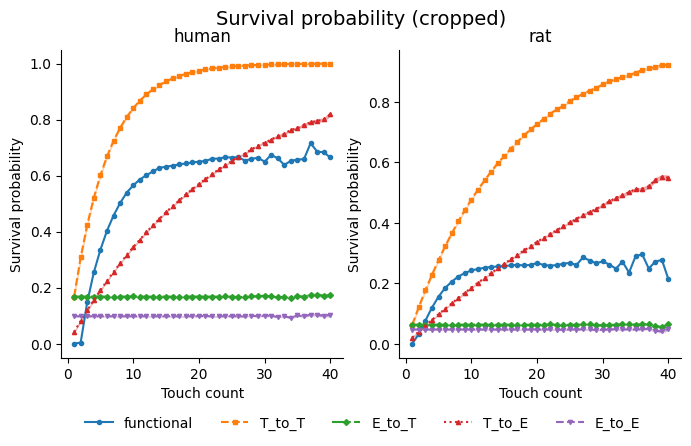

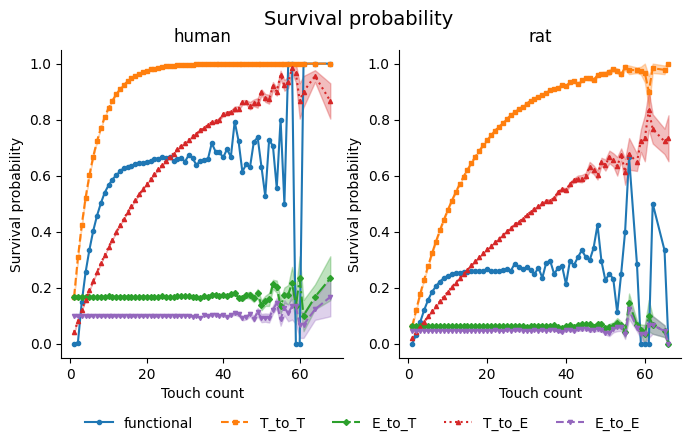

In [4]:
for cropped in [True, False]: # Cropped =False plots all values, cropped=True cuts the x-axis to not consider noise
    fig, axs = plt.subplots(1,2, figsize=figsize,sharey=sharey)
    for i, animal in enumerate(["human", "rat"]):
        ax=axs[i] 
        DF=survival_prob[animal]
        for prunning_name in DF.keys():
            if prunning_name=="functional":
                df=DF[prunning_name]
                if cropped:
                    df=df.loc[df.index <= max_range[animal]]
                ax.plot(df, label=prunning_name, color=colors[prunning_name], linestyle=line_styles[prunning_name], marker=markers[prunning_name], markersize=markersize)
            else:
                df=pd.DataFrame.from_dict(DF[prunning_name])
                if cropped:
                    df=df.loc[df.index <= max_range[animal]]
                mean=df.mean(axis=1)
                sem=df.sem(axis=1)
                ax.fill_between(df.index, mean-sem, mean+sem, alpha=0.3, color=colors[prunning_name])
                ax.plot(mean, label=prunning_name, color=colors[prunning_name], linestyle=line_styles[prunning_name], marker=markers[prunning_name], markersize=markersize)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_title(animal)
        ax.set_xlabel("Touch count")
        ax.set_ylabel("Survival probability")
    axs[1].legend(frameon=False, ncols=5,bbox_to_anchor=(0.9,-.15))
    label="(cropped)" if cropped else ""
    fig.suptitle(f"Survival probability {label}", fontsize=14)
    fig.savefig(f"figures/Survival_probability_{label}.pdf", dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig(f"figures/Survival_probability_{label}.svg", dpi=300, bbox_inches="tight", transparent=True)
